<h1 align="center"><font size="6"> Lab 2: Newton and quasi-Newton methods </font> (gradient descent, part 2)</h1>
<hr> 

**Report by Ugo Roccamatisi.**


<h1>Contents</h1>

<div class="alert alert-block alert-info" style="margin-top : 20px">
      <ul>
          <li><a href="#prelim">Preliminaries</a></li>
          <li><a href="#Newton">Newton's method</a></li>
          <li><a href="#BFGS">A quasi-Newton method (BFGS)</a></li>
      </ul>
</div>
<br>
<h>

<a id='prelim'></a>
<h2>Preliminaries</h2>
<hr>

We start by importing the required libraries (_numpy_ and _matplotlib.pyplot_).

We also define two visualization functions for *1/* the level lines of the objective function and *2/* the gradient field (for objective functions of two variables). 

There is also an example of the plot used to observe the convergence speed of the optimization methods.

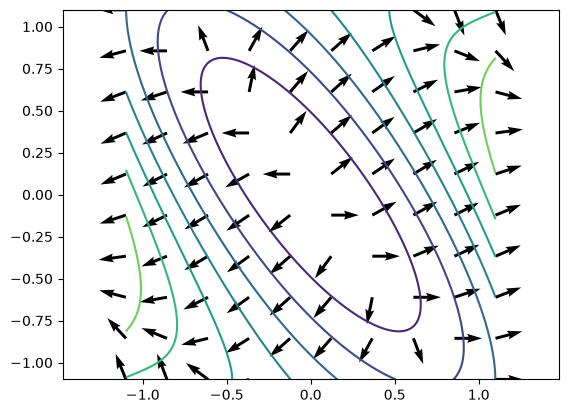

In [1]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def draw_vector_field(F, xmin, xmax, ymin, ymax, N=15):
    X = np.linspace(xmin, xmax, N)  
    # x coordinates of the grid points
    Y = np.linspace(ymin, ymax, N)  
    # y coordinates of the grid points
    U, V = F(*np.meshgrid(X, Y))  # vector field
    M = np.hypot(U, V)  # compute the norm of (U,V)
    M[M == 0] = 1  # avoid division by 0
    U /= M  # normalize the u component
    V /= M  # normalize the v component
    return plt.quiver(X, Y, U, V, angles='xy')

def level_lines(f, xmin, xmax, ymin, ymax, levels, N=500):
    x = np.linspace(xmin, xmax, N)
    y = np.linspace(ymin, ymax, N)
    z = f(*np.meshgrid(x, y))
    level_l = plt.contour(x, y, z, levels=levels)
    #plt.clabel(level_l, levels, fmt='%.1f') 

f = lambda x, y : np.cosh(x)+ np.sin(x + y)**2
df = lambda x, y : np.array([np.sinh(x) 
                             + 2*np.cos(x + y)*np.sin(x + y), 
                             2*np.cos(x + y)*np.sin(x + y)])
%matplotlib inline
level_lines(f, -1.1, 1.1, -1.1, 1.1, np.linspace(1, 3, 10))
draw_vector_field(df, -1.1, 1.1, -1.1, 1.1, 10)
plt.axis('equal')
plt.show()


<a id='Newton'></a>
<h2>Newton's method</h2>
<hr>

In this lab we assume that $f:\mathbb{R}^N\to\mathbb{R}$ is at least $C^2$.

Newton's method (or Newton-Raphson) is an iterative descent method in which the descent direction at step $k$ minimizes the second-order Taylor expansion of $f$ at $x^k$, i.e.
$$
\tag{4}
m_k(d):=f(x^k) + d\cdot \nabla f(x^k) + \dfrac12 d^T D^2 f(x^k) d.
$$
If the (symmetric) matrix $D^2 f(x^k)$ is positive definite, the minimizer of $m_k$ exists and is unique. We denote by $H^k$ the inverse of $D^2 f(x^k)$, $g^k:=\nabla f(x^k)$ and $d^k$ the minimizer of (4).

***Question 15.*** Express $d^k$ as a function of $H^k$ and $g^k$.

___Solution:___ $d^k=-H^kg^k$.

Once the descent direction $d^k$ is computed, we proceed as in gradient descent and use backtracking ($\alpha \leftarrow \beta\alpha$) to find $\alpha_k$ such that $f(x^k+ \alpha_k d^k)$ is "sufficiently smaller" than $f(x^k)$. To quantify "sufficiently smaller", we again use the Armijo criterion: 

$$
\tag{5}
f(x^k+\alpha_kd^k)\, \le\, f(x^k) + c\, \alpha_k \left<d^k;g^k\right>,
$$
where $c\in(0,1)$ is fixed. We use the same backtracking method.

The Newton-Raphson algorithm with an Armijo line search then reads: 

First, fix $c,\beta\in(0,1)$ and choose $x^0\in\mathbb{R}^N$.
<br> 
Then, for $k=0,1,\dots$ until convergence, repeat:
$$
\left|
\begin{array}{l}
\text{Compute }d^k,\\
\text{Find }\alpha_k>0 \text{ such that (5) holds,}\\
\text{Set }x^{k+1}\,\leftarrow\,x^k + \alpha_k d^k.
\end{array}
\right.
$$

An important point is that when $x^k$ is close enough to a local minimizer $x^*$ of $f$ with $D^2f(x^*)$ positive definite, the choice $\alpha_k=1$ gives quadratic convergence to $x^*$, _i.e._ 
$$
\|x^{k+1}-x^*\|\leq C \|x^k - x^*\|^2.
$$
To keep this superlinear convergence, we must choose $\alpha_k=1$ as soon as $x^k$ is close enough to $x^*$. To do so, the backtracking iterations start at $\alpha=1$ and we choose a relatively small $c$ in (5) (for example $c=0.1$).
<br>

Let $\Lambda>0$. We set $f_\Lambda(x,y):=(1-x)^2 + \Lambda\,(y-x^2)^2$, for $(x,y)\in\mathbb{R}^2$ (the Rosenbrock function). 

__Question 16.__ Compute $\nabla f_\Lambda(x,y)$. Find the minimizer(s) of $f_\Lambda$. Plot a few level lines of $f_\Lambda$ and the normalized vector field $(1/|\nabla f_\Lambda|)\nabla f_\Lambda$ for $\Lambda=100$. Compute $D^2 f(x,y)$ and its inverse $H_\Lambda(x,y)$.

**Solution 16.** $\nabla f_\Lambda=(2(x-1)+4\Lambda x(x^2-y),\ 2\Lambda(y-x^2))^T$. Since $f_\Lambda=(x-1)^2+\Lambda(y-x^2)^2\ge0$, the unique minimizer is $(1,1)$ for $\Lambda>0$. Its Hessian is $\begin{pmatrix}2-4\Lambda y+12\Lambda x^2&-4\Lambda x\\-4\Lambda x&2\Lambda\end{pmatrix}$; when it is invertible, $H_\Lambda=(\nabla^2 f_\Lambda)^{-1}$. The Hessian is not necessarily positive everywhere, even though it is at the minimizer.

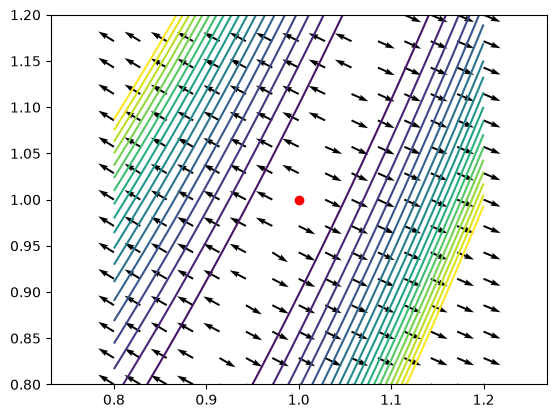

In [2]:
Lambda = 100
f = lambda x,y : ( x - 1)**2 + Lambda*(y - x**2)**2
df = lambda x,y : np.array([2*(x - 1) + 4*Lambda*x*(x**2 - y), 2*Lambda*(y - x**2)])
ddf = lambda x,y : np.array([[2 - 4*Lambda*y + 12*Lambda*x**2 , -4*Lambda*x], [-4*Lambda*x, 2*Lambda]])
HH = lambda x,y : np.linalg.inv(ddf(x,y))

%matplotlib inline
level_lines(f, .8, 1.2, .8, 1.2, np.linspace(0, 20, 20))
draw_vector_field(df, .8, 1.2, .8, 1.2, 15)
plt.plot(1,1,'or')
plt.axis('equal')
plt.show()

__Question 17.__ Implement Newton's method and apply it to the function above with $c=0.1$, $\beta=0.75$ and $x^0=(0,0)$. Plot the iterates and $\ \log(f_\Lambda(x^k))\ $ as a function of $k$. Comment on the results.

_Hint:_ First test the algorithm on the quadratic function below.

In [3]:
# For testing
'''
f = lambda x,y : ( x - 1)**2 + 2*(y - 1)**2
df = lambda x,y : np.array([2*(x - 1) , 4*(y - 1)])
#ddf = lambda x,y : np.array([[2  , 0], [0, 2]])
HH = lambda x,y : np.array([[.5, 0], [0, .25]])
'''
Lambda = 1000
f = lambda x,y : ( x - 1)**2 + Lambda*(y - x**2)**2
df = lambda x,y : np.array([2*(x - 1) + 4*Lambda*x*(x**2 - y), 2*Lambda*(y - x**2)])
ddf = lambda x,y : np.array([[2 - 4*Lambda*y + 12*Lambda*x**2 , -4*Lambda*x], [-4*Lambda*x, 2*Lambda]])
HH = lambda x,y : np.linalg.inv(ddf(x,y))

In [4]:
## Parameters
c, beta = .1, .75
epsilon = 1e-8
itermax = 100
iter_ls_max = 20

## Initialization
w =np.array([0.2,0])
fw = f(*w)
g = np.array(df(*w))
ng=np.hypot(*g)
ng0=ng
iteration = 0

## For post-processing
W, F, NG, Iter_ls =[w], [fw], [ng], []

In [5]:
## Optimization loop
while (iteration < itermax) and ng > epsilon*ng0 :
    iteration += 1
    d = -np.dot(HH(*w), g)
    
    # Step size alpha
    coef_armijo = -c*np.dot(d,g)
    t = 1
    new_w =w + t*d
    new_fw = f(*new_w) 
    iter_ls = 0
    while (iter_ls<iter_ls_max) and (new_fw > fw + t*coef_armijo):
        t *=beta
        new_w =w + t*d
        new_fw = f(*new_w) 
        iter_ls += 1
            
    w, fw = new_w, new_fw
    g = df(*w)
    ng=np.hypot(*g)
    
    W.append(w)
    F.append(fw)
    NG.append(ng)
    Iter_ls.append(iter_ls)

number of iterations = 21


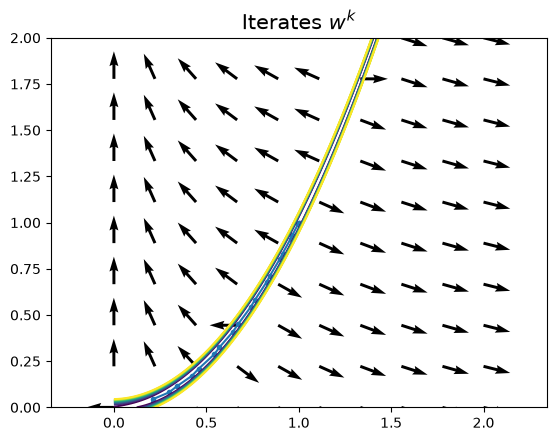

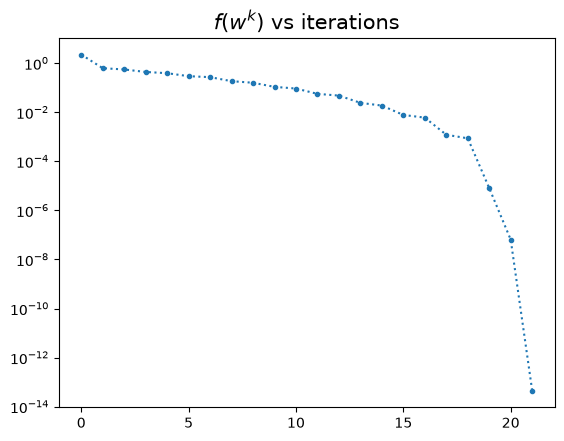

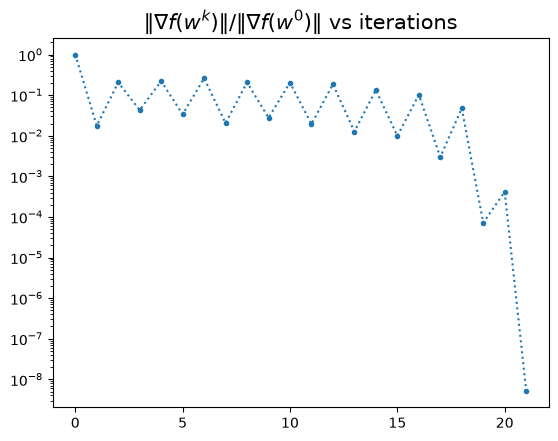

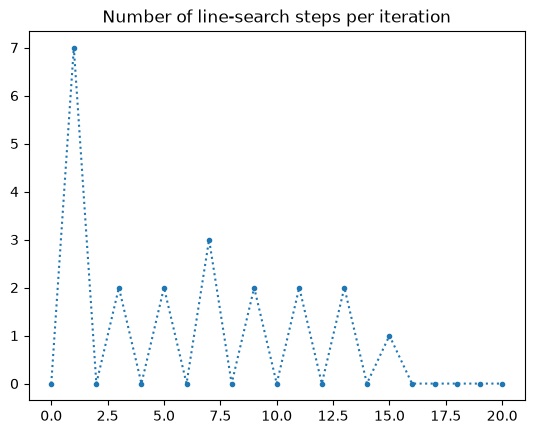

In [6]:
print(f"number of iterations = {iteration}")    
    
W = np.array(W)
F = np.array(F)

# Plots
plt.figure()
plt.plot(W[:,0],W[:,1],'.',linestyle='-')
level_lines(f, 0, 2, 0, 2, np.linspace(1, 3, 10))
draw_vector_field(df, 0 , 2, 0, 2, 10)
plt.title(r"Iterates $w^k$", fontsize=15)
plt.axis('equal')
plt.show()

# Values of f along the iterations.
plt.figure()
plt.semilogy(range(len(F)),F,'.',linestyle=':')
plt.title(r"$f(w^k)$ vs iterations", fontsize=15)
plt.show()

# ||grad f|| along the iterations.
plt.figure()
plt.semilogy(range(len(NG)),np.array(NG)/ng0,'.',linestyle=':')
plt.title(r"$\|\nabla f(w^k)\|/\|\nabla f(w^0)\|$ vs iterations", 
          fontsize=15)
plt.show()

# # Number of line-search steps along the iterations.
plt.figure()
plt.plot(range(len(Iter_ls)),Iter_ls,'.',linestyle=':')
plt.title(r"Number of line-search steps per iteration", fontsize=12)
plt.show()

__Comments__: Both regimes of Newton's method are clearly visible: first a rather slow approach to the minimizer, then extremely fast convergence, which corresponds to the Armijo criterion systematically accepting the step $\alpha=1$.

<a id='BFGS'></a>
<h2>A quasi-Newton method (BFGS)</h2>
<hr>

When the number of parameters is large, as is usual in machine learning, computing the Hessian matrices $D^2f(x^k)$ and solving the linear systems $D^2f(x^k) d^k=-g^k$ can be too expensive. However, superlinear convergence can often still be achieved by replacing $[D^2f(x^k)]^{-1}$ with a cheaper approximation, denoted $H^k$. Several algorithms are based on this idea. We present one of the most popular: the BFGS method, named after its discoverers (Broyden, Fletcher, Goldfarb and Shanno). 

__Description of the method__: Assume that at step $k$ we have a symmetric positive-definite approximation $H^k$ of $\left[D^2f(x^k)\right]^{-1}$. Denote by $B^k$ its inverse (an approximation of $D^2f(x^k)$). As above, the descent direction $d^k$ is the minimizer of
$$
f(x^k) + d\cdot \nabla f(x^k) + \dfrac12 d^T B^k d.
$$
This gives:
$$
d^k = -\left[B^k\right]^{-1} \nabla f(x^k) = - H^k g^k. 
$$

We then look for $\alpha_k$ satisfying (5) by backtracking, still starting from $\alpha=1$, and set
$$
x^{k+1} := x^k +\alpha_k d^k.
$$

We now need an approximation $H^{k+1}$ of $\left[D^2f(x^{k+1})\right]^{-1}$. Recall that we want
$$
\tilde m_{k+1} (d):= f(x^{k+1}) + g^{k+1}\cdot d +\dfrac 12 d^T B^{k+1} d,
$$
to approximate
$$
\overline m_{k+1}(d):= f(x^{k+1} + d).
$$
By construction, we already have
$$
\tilde m_{k+1}(0)=\overline m_{k+1}(0)=f(x^{k+1})\qquad\text{and}\qquad \nabla \tilde m_{k +1}(0)=\nabla \overline m_{k+1}(0)=g(x^{k+1}).
$$
We impose the new condition
$$
\nabla m_{k+1}(-\tau_k d^k)=\nabla \overline m_{k+1}(-\tau_k d^k)=g^k.
$$

With $a^k:=g^{k+1}-g^k$ and $b^k:=\tau^kd^k=x^{k+1}-x^k$, this is equivalent to $B^{k+1}b^k=a^k$. Assuming $B^{k+1}$ is invertible, this amounts to requiring that $H^{k+1}$ solves
$$
\tag{6}
Ha^k=b^k.
$$
A necessary and sufficient condition for (6) to have a symmetric positive-definite solution $H$ is:
$$
\tag{7}
\left<a^k;b^k\right> >0.
$$

We do not want to lose all the information already contained in $H^k$, so, assuming (7) holds, we choose a solution of (6) as close as possible to $H^k$. A popular choice is:
$$
\tag{8}
H^{k+1} := \left(I-\rho_k b^k\otimes a^k\right) H^k \left(I-\rho_k a^k\otimes b^k\right) + \rho_k b^k\otimes b^k,\quad\text{ with }\quad \rho_k:=\dfrac1{\left<a^k;b^k\right>}.
$$

__Question 18.__ Check that formula (8) gives a solution of (6). Check that $H^{k+1}$ defined this way is symmetric positive definite.

___Solution:___
Assuming $H^k$ is positive definite and (7) holds, it is easy to check that $H^{k+1}$ is also positive definite. First, for $d\in \mathbb{R}^N$, with $w=d-\rho_k \left<b^k;d\right>a^k$, we compute

$$
  d^TH^{k+1}d = w^TH^kw + \rho_k \left<d;b^k\right>^2\ \geq \ 0.
$$

Then, by the same formula, $d^TH^{k+1}d=0$ implies (a) $w=0$ and (b) $\left<d;b^k\right>=0$. Point (a) gives $d=\lambda a^k$ for some $\lambda\in \mathbb{R}$, and with (b) we get $\lambda\left<a^k;b^k\right>=0$. Hence $\lambda=0$ and $d=0$, which proves that $H^{k+1}$ is positive definite.

**Secant equation.** With $\rho=1/(a^Tb)$, $(I-\rho ba^T)H(I-\rho ab^T)a=0$ since $(I-\rho ab^T)a=0$, and $\rho bb^Ta=b$: the update does satisfy $H^{k+1}a=b$.


__Question 19.__ Implement the BFGS method and apply it to the function above with $c = 0.1$, $\beta=0.75$ and $x^0=(0,0)$. As a first approximation of $[D^2f(x^0)]^{-1}$, take $H^0=I$.

Plot the iterates and $\ \log(f(x^k))\ $ as a function of $k$. Observe and comment.

__Question 20.__ Does $H^k$ converge to $[D^2 f(x^*)]^{-1}$?

**Answer 20.** In this experiment, the final relative error between $H^k$ and the true inverse Hessian is about **0.00282**: the approximation is good, but not exact. Convergence of $H^k$ requires additional assumptions and does not follow from the convergence of the iterates alone.


In [7]:
# For testing
'''
f = lambda x,y : ( x - 1)**2 + 2*(y - 1)**2
df = lambda x,y : np.array([2*(x - 1) , 4*(y - 1)])
#ddf = lambda x,y : np.array([[2  , 0], [0, 2]])
HH = lambda x,y : np.array([[.5, 0], [0, .25]])
'''
Lambda = 1000
f = lambda x,y : ( x - 1)**2 + Lambda*(y - x**2)**2
df = lambda x,y : np.array([2*(x - 1) + 4*Lambda*x*(x**2 - y), 2*Lambda*(y - x**2)])
ddf = lambda x,y : np.array([[2 - 4*Lambda*y + 12*Lambda*x**2 , -4*Lambda*x], [-4*Lambda*x, 2*Lambda]])
HH = lambda x,y : np.linalg.inv(ddf(x,y))

In [8]:
## Parameters
c, beta = .1, .75
epsilon = 1e-8
itermax = 100
iter_ls_max = 20

## Initialization
w =np.array([0,0])
fw = f(*w)
g = np.array(df(*w))
ng=np.hypot(*g)
ng0=ng

Id = np.eye(2)
H=Id
true_H = HH(*w)
err_H = np.linalg.norm(H-true_H)/np.linalg.norm(true_H)

iteration = 0

## For post-processing
Err_H, W, F, NG, Iter_ls =[err_H], [w], [fw], [ng], []

In [9]:
## Optimization loop
while (iteration < itermax) and ng > epsilon*ng0 :
    iteration += 1
    d = - H@g
    
    # Step size alpha
    coef_armijo = -c*np.dot(d,g)
    t = 1
    new_w =w + t*d
    new_fw = f(*new_w) 
    iter_ls = 0
    while (iter_ls<iter_ls_max) and (new_fw > fw + t*coef_armijo):
        t *=beta
        new_w =w + t*d
        new_fw = f(*new_w) 
        iter_ls += 1

    b = new_w - w 
    w, fw = new_w, new_fw
    new_g = df(*w)
    a = new_g - g
    g = new_g
    ng=np.hypot(*g)

    rho = 1/(a.dot(b))
    H=(Id - rho*np.tensordot(b,a,axes=0))@H@(Id - rho*np.tensordot(a,b,axes=0) ) + rho*np.tensordot(b,b,axes=0)
    
    true_H = HH(*w)
    err_H = np.linalg.norm(H-true_H)/np.linalg.norm(true_H)
    Err_H.append(err_H)
    W.append(w)
    F.append(fw)
    NG.append(ng)
    Iter_ls.append(iter_ls)
    

number of iterations = 55


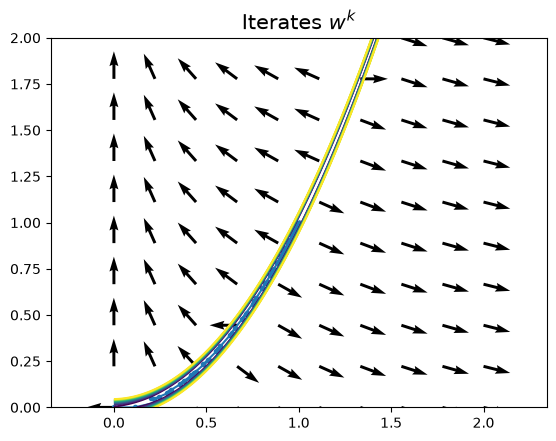

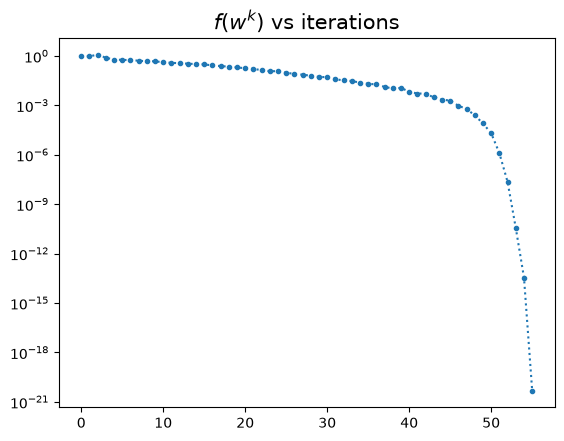

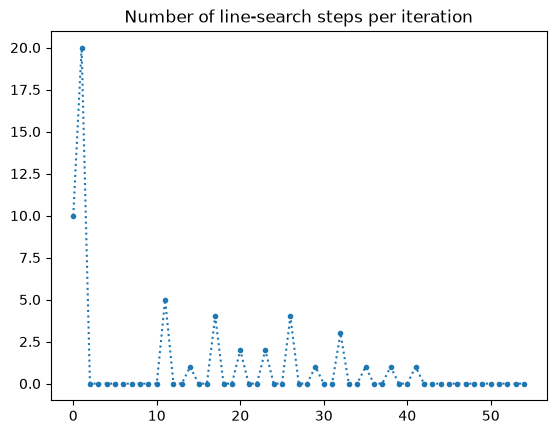

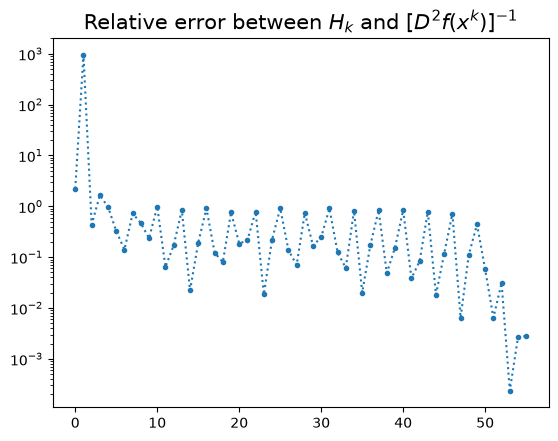

Final distance to (1,1): 1.1773837137587174e-10
Final relative error of the inverse Hessian: 0.002820858107448469


In [10]:
print(f"number of iterations = {iteration}")    
    
W = np.array(W)
F = np.array(F)

# Plots
plt.figure()
plt.plot(W[:,0],W[:,1],'.',linestyle='-')
level_lines(f, 0, 2, 0, 2, np.linspace(1, 3, 10))
draw_vector_field(df, 0 , 2, 0, 2, 10)
plt.title(r"Iterates $w^k$", fontsize=15)
plt.axis('equal')
plt.show()

# Values of f along the iterations.
plt.figure()
plt.semilogy(range(len(F)),F,'.',linestyle=':')
plt.title(r"$f(w^k)$ vs iterations", fontsize=15)
plt.show()


# Number of line-search steps along the iterations.
plt.figure()
plt.plot(range(len(Iter_ls)),Iter_ls,'.',linestyle=':')
plt.title(r"Number of line-search steps per iteration", fontsize=12)
plt.show()

# Relative error of H_k along the iterations.
plt.figure()
plt.semilogy(range(len(Err_H)),Err_H,'.',linestyle=':')
plt.title(r"Relative error between $H_k$ and $[D^2f(x^k)]^{-1}$", fontsize=15)
plt.show()

print("Final distance to (1,1):", np.linalg.norm(W[-1]-np.array([1.,1.])))
print("Final relative error of the inverse Hessian:", Err_H[-1])


Again, two successive convergence regimes appear: a relatively slow linear convergence, then very fast convergence in 4 or 5 iterations, once the step $\alpha=1$ is accepted by the Armijo criterion.

The method needs about twice as many iterations as Newton's method for the requested accuracy. However, it does not solve the linear system $D^2f(w^k) d^k =-g^k$ at each iteration; this solve (very expensive for large, ill-conditioned systems) is the weakness of Newton's method.

The matrix $H^k$ approximating $[D^2f(w^k)]^{-1}$ gets close to $[D^2f(w^*)]^{-1}$ (final relative error of about 0.3%).